
--- Unscaled Weights (θ) ---
[[  -14.41951716   -14.9289624  -1178.17782585]
 [   23.15489348    19.01904572 -1632.64334229]
 [   -8.73537632    -4.09008332  2810.82116814]]

--- Unscaled Intercepts (Bias) ---
[  5100.8537339    6453.92773427 -11554.78146817]
              precision    recall  f1-score   support

     Economy       1.00      1.00      1.00        20
      Luxury       0.85      0.85      0.85        20
         SUV       0.85      0.85      0.85        20

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



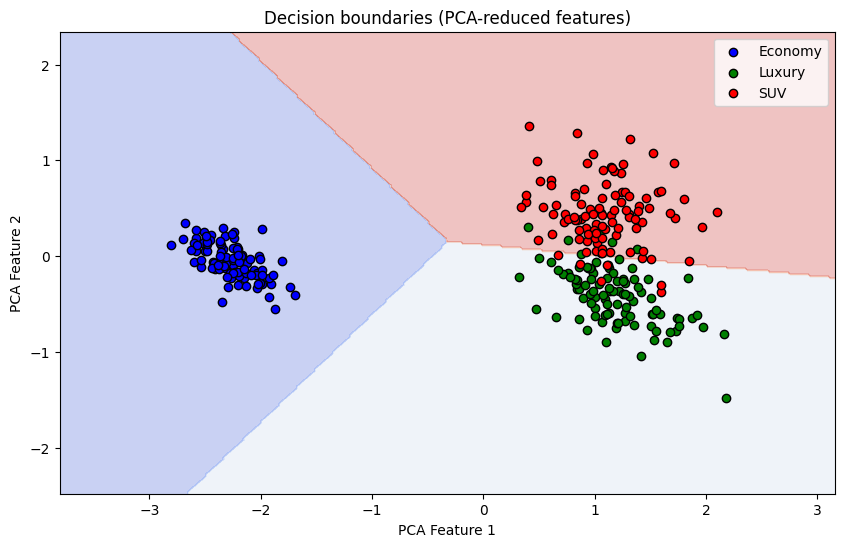

In [5]:
# Softmax regression example using scikit-learn with synthetic car data

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Synthetic dataset: Car type classification
np.random.seed(42)
n_samples = 300

# Economy cars
price_economy = np.random.normal(15, 2, n_samples // 3)
length_economy = np.random.normal(160, 5, n_samples // 3)
weight_economy = np.random.normal(2500, 100, n_samples // 3)
labels_economy = np.zeros(n_samples // 3)

# Luxury cars
price_luxury = np.random.normal(40, 5, n_samples // 3)
length_luxury = np.random.normal(190, 5, n_samples // 3)
weight_luxury = np.random.normal(4000, 200, n_samples // 3)
labels_luxury = np.ones(n_samples // 3)

# SUVs
price_suv = np.random.normal(35, 4, n_samples // 3)
length_suv = np.random.normal(185, 6, n_samples // 3)
weight_suv = np.random.normal(4500, 300, n_samples // 3)
labels_suv = np.full(n_samples // 3, 2)

# Combine all data
X = np.vstack([ 
    np.stack([price_economy, length_economy, weight_economy], axis=1), 
    np.stack([price_luxury, length_luxury, weight_luxury], axis=1),
    np.stack([price_suv, length_suv, weight_suv], axis=1),
])
y = np.concatenate([labels_economy, labels_luxury, labels_suv])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Train softmax regression model (multinomial logistic regression)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Reverse the scaling for weights
weights_original_scale = model.coef_ * scaler.scale_

# Reverse the scaling for intercepts
intercepts_original_scale = model.intercept_ - np.dot(scaler.mean_, model.coef_.T)

# Print unscaled values
print("\n--- Unscaled Weights (θ) ---")
print(weights_original_scale)

print("\n--- Unscaled Intercepts (Bias) ---")
print(intercepts_original_scale)


# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Economy", "Luxury", "SUV"]))

# Optional: visualize decision boundaries (only works with 2 features)
# Here, we'll reduce to 2D for illustration
X_2d = PCA(n_components=2).fit_transform(X_scaled)

model_2d = LogisticRegression(solver='lbfgs', max_iter=1000)
model_2d.fit(X_2d, y)

h = .02  # step size in the mesh
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

# Scatter plot using matplotlib only
colors = ['blue', 'green', 'red']
labels = ['Economy', 'Luxury', 'SUV']
for class_value in np.unique(y):
    plt.scatter(X_2d[y == class_value, 0], X_2d[y == class_value, 1],
                c=colors[int(class_value)], label=labels[int(class_value)], edgecolor='k')

plt.title("Decision boundaries (PCA-reduced features)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()


In [4]:
new_car = np.array([[38, 188, 4100]])  # Shape (1, 3)
new_car_scaled = scaler.transform(new_car)  # Use the same scaler from training

predicted_class = model.predict(new_car_scaled)
predicted_label = ["Economy", "Luxury", "SUV"][int(predicted_class[0])]

print(f"Predicted car type: {predicted_label}")


Predicted car type: Luxury
